In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
sns.set(style="whitegrid")

## DATA SET DC

# LAB1: Dataset Exploration

 ### Load Dataset 
ผมเริ่มจากโหลดไฟล์ CSV เข้ามาเก็บในตัวแปรที่เรียกว่า DataFrame ด้วยคำสั่ง pd.read_csv() แล้วดูตัวอย่าง 5 แถวแรกด้วย .head() เพื่อเช็คก่อนว่าไฟล์ถูกอ่านเข้ามาถูกต้อง ไม่มีอะไรผิดเพี้ยนตั้งแต่ต้นทาง

In [10]:
df = pd.read_csv("comic_characters.csv")
df.head()

,Id,Name,Identity,Alignment,Eyes,Hair,Sex,Alive,Appearances,First_appeared,Planet,Universe
0,0,Dave Finn,Secret,Good,Blue,Black,Male,Yes,1,"2002, July",Earth-616,Marvel
1,1,Katherine Power,Secret,Good,Blue,Red,Female,Yes,106,"1984, August",Earth-616,Marvel
2,2,John Malone,Secret,Bad,Blue,White,Male,Yes,15,"1985, January",New Earth,DC
3,3,"Samuel Bradley, Jr.",Public,Bad,Brown,Brown,Male,No,19,"2004, March",New Earth,DC
4,4,Hope Taya,Public,Bad,Brown,Black,Female,Yes,28,"1999, December",New Earth,DC


### Display Shape
ผมดูขนาดข้อมูลด้วย df.shape ได้เป็นคู่ตัวเลข (จำนวนแถว, จำนวนคอลัมน์) ครับ อันนี้สำคัญเพราะทำให้ผมรู้ว่ามีข้อมูลมากพอจะวิเคราะห์ไหม และเป็นฐานในการประเมินว่าถ้าต้องลบข้อมูลบางส่วนทิ้งในขั้นถัดไป จะกระทบมากน้อยแค่ไหน

In [11]:
print("Shape:", df.shape)

Shape: (21144, 12)


### Display Data Types
ผมเช็คด้วย df.dtypes ว่าแต่ละคอลัมน์ pandas อ่านเป็นชนิดข้อมูลอะไร เพราะบางครั้งคอลัมน์ที่ควรเป็นตัวเลขหรือวันที่ ดันถูกอ่านเป็นข้อความ (object) เนื่องจากมีค่าผิดปกติปนอยู่ ผมต้องรู้จุดนี้ไว้ก่อนเพื่อไปแก้ในขั้น Data Type Conversion ทีหลัง

In [12]:
print(df.dtypes)

Id                int64
Name                str
Identity            str
Alignment           str
Eyes                str
Hair                str
Sex                 str
Alive               str
Appearances       int64
First_appeared      str
Planet              str
Universe            str
dtype: object


### Display Summary Statistics
ผมใช้ df.describe() เพื่อดูค่าเฉลี่ย ค่าต่ำสุด สูงสุด และควอไทล์ของคอลัมน์ตัวเลข ตัวเลขพวกนี้เป็นสัญญาณเตือนเบื้องต้นครับ เช่น ถ้าค่า max สูงผิดปกติเทียบกับ mean แปลว่าอาจมี outlier ซ่อนอยู่

In [13]:
print(df.describe())                    
print(df.describe(include="object"))

                 Id   Appearances
count  21144.000000  21144.000000
mean   10571.500000     19.329502
std     6103.891382     94.444348
min        0.000000      1.000000
25%     5285.750000      1.000000
50%    10571.500000      4.000000
75%    15857.250000     10.000000
max    21143.000000   4043.000000
           Name Identity Alignment   Eyes   Hair    Sex  Alive  \
count     21144    21144     21144  21144  21144  21144  21144   
unique    19959        5         3     24     20      6      2   
top     Charlie   Secret       Bad   Blue  Black   Male    Yes   
freq         10    10452     10250   6656   6688  14964  16050   

         First_appeared     Planet Universe  
count             21144      21144    21144  
unique              899         26        2  
top     2006, September  Earth-616   Marvel  
freq                103      14607    14665  


C:\Users\asus\AppData\Local\Temp\ipykernel_53764\2019652446.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


### Display Missing Values
 ผมนับด้วย df.isnull().sum() ว่าแต่ละคอลัมน์มีค่าที่หายไปกี่ค่า เพราะโมเดล ML ส่วนใหญ่เทรนกับค่าว่างไม่ได้ ผมต้องรู้ก่อนว่าจะเติมค่าหรือลบทิ้งในขั้น Data Cleaning

In [14]:
print(df.isnull().sum())
print((df.isnull().sum() / len(df) * 100).round(2))

Id                0
Name              0
Identity          0
Alignment         0
Eyes              0
Hair              0
Sex               0
Alive             0
Appearances       0
First_appeared    0
Planet            0
Universe          0
dtype: int64
Id                0.0
Name              0.0
Identity          0.0
Alignment         0.0
Eyes              0.0
Hair              0.0
Sex               0.0
Alive             0.0
Appearances       0.0
First_appeared    0.0
Planet            0.0
Universe          0.0
dtype: float64


### Display Duplicate Records
ผมเช็คด้วย df.duplicated().sum() ว่ามีแถวที่ข้อมูลซ้ำกันทุกคอลัมน์ไหม เพราะถ้าไม่ลบออก โมเดลจะเห็นข้อมูลชุดนั้นซ้ำเหมือนสำคัญกว่าชุดอื่น ทำให้ผลลัพธ์เอนเอียง

In [15]:
print("จำนวนแถวซ้ำ:", df.duplicated().sum())
df[df.duplicated()]

จำนวนแถวซ้ำ: 0


,Id,Name,Identity,Alignment,Eyes,Hair,Sex,Alive,Appearances,First_appeared,Planet,Universe


### Display Class Distribution
ผมดูสัดส่วนของ class เป้าหมายด้วย value_counts() เช่นดูว่า DC กับ Marvel มีจำนวนตัวละครต่างกันแค่ไหน ถ้าสัดส่วนต่างกันมากเรียกว่า imbalanced ซึ่งต้องระวังตอนสร้างโมเดลจำแนกประเภทในอนาคต

In [16]:
print(df["Universe"].value_counts())
print(df["Alignment"].value_counts())

Universe
Marvel    14665
DC         6479
Name: count, dtype: int64
Alignment
Bad        10250
Good        7957
Neutral     2937
Name: count, dtype: int64


# LAB2: Data Visualization

### Histogram
ผมใช้ df.hist() วาดกราฟแท่งแสดงการกระจายตัวของแต่ละคอลัมน์ตัวเลข ทำให้เห็นว่าข้อมูลเบ้ไปทางไหน กระจุกตัวช่วงไหน และเห็น outlier เป็นแท่งโดดเดี่ยวที่แยกออกจากกลุ่มหลักอย่างชัดเจน

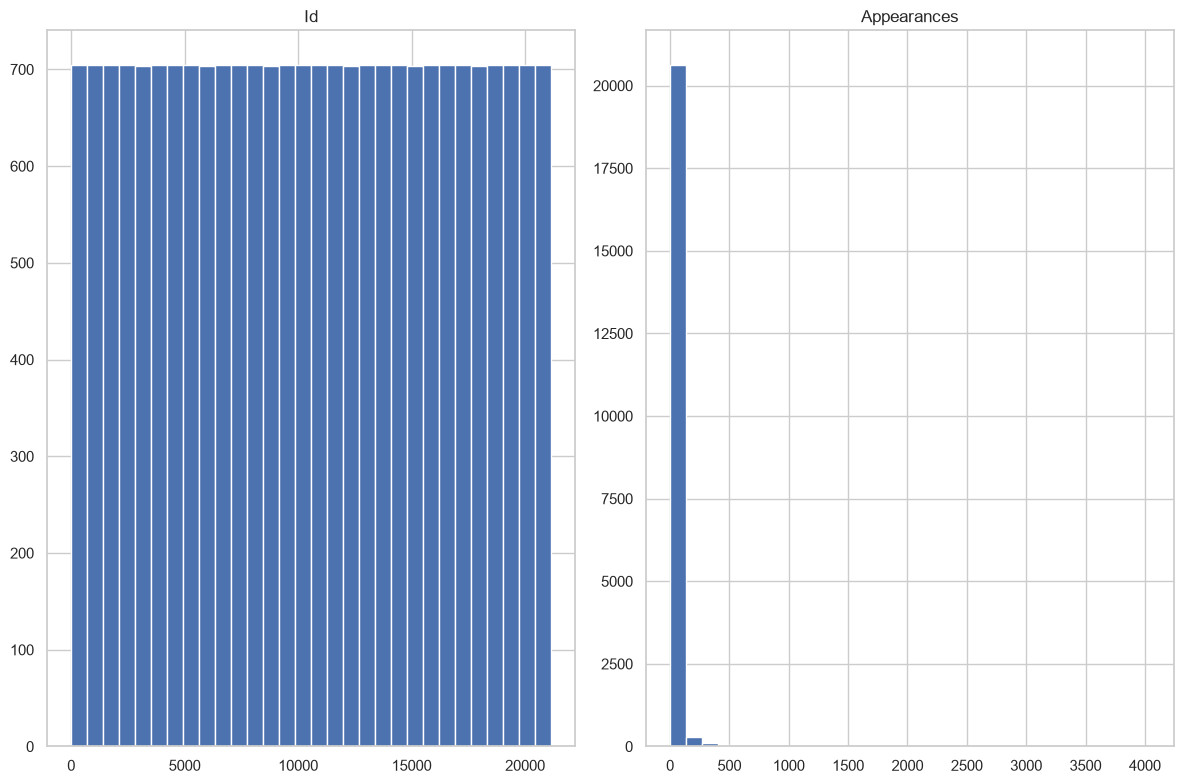

In [17]:
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

### Correlation Heatmap
ผมใช้ sns.heatmap(df.corr()) แสดงความสัมพันธ์ระหว่างตัวแปรตัวเลข ค่าใกล้ +1 หรือ -1 หมายถึงสัมพันธ์กันแรง ถ้าเจอสองตัวแปรที่สัมพันธ์กันสูงมาก ผมจะพิจารณาตัดตัวใดตัวหนึ่งออกในภายหลัง เพราะมันให้ข้อมูลซ้ำซ้อนกันในเชิงความหมาย

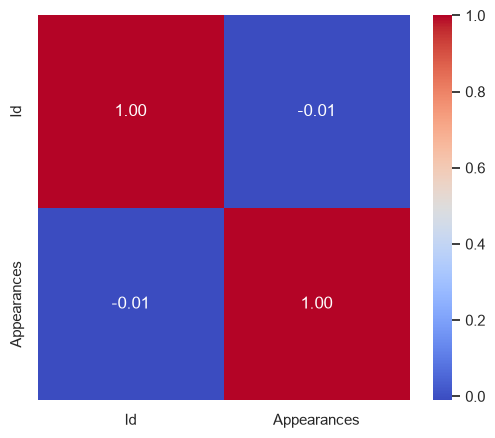

In [18]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

# LAB3: Data Cleaning

### Missing Value Handling
ผมเติมค่าที่หายไป (impute) แทนการลบทิ้งทั้งแถว เพราะจะเสียข้อมูลน้อยกว่า สำหรับคอลัมน์ตัวเลขผมใช้ median เพราะทนทานต่อ outlier มากกว่า mean ส่วนคอลัมน์ข้อความผมใช้ mode คือค่าที่พบบ่อยที่สุด

In [19]:
print("ก่อนแก้:", df.isnull().sum().sum())

categorical_cols = ["Identity", "Alignment", "Eyes", "Hair", "Sex", "Alive", "Planet"]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df["Appearances"] = df["Appearances"].fillna(df["Appearances"].median())

print("หลังแก้:", df.isnull().sum().sum())

ก่อนแก้: 0
หลังแก้: 0


### Duplicate Removal
ผมใช้ drop_duplicates() ลบแถวที่ซ้ำออก ให้เหลือข้อมูลที่ไม่ซ้ำกันเท่านั้น ป้องกันไม่ให้โมเดลเรียนรู้ผิดเพี้ยนจากข้อมูลชุดเดียวกันที่ถูกนับซ้ำ

In [20]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"ลบข้อมูลซ้ำออก {before - after} แถว")

ลบข้อมูลซ้ำออก 0 แถว


###  Incorrect Data Correction
ผมแก้ข้อมูลที่ไม่สอดคล้องกัน (inconsistent) เช่น ข้อความที่มีทั้งตัวพิมพ์ใหญ่เล็กปนกันหรือมีช่องว่างเกินมา ด้วย .str.strip().str.title() ให้เป็นรูปแบบเดียวกันหมด และตรวจ outlier ด้วยหลัก IQR เพื่อดูว่าค่าไหนต่ำ/สูงเกินขอบเขตปกติ แล้วตัดสินใจว่าจะแก้ไขหรือปล่อยไว้ตามบริบทของข้อมูลจริง

In [21]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# ตรวจ outlier ของ Appearances ด้วย IQR
Q1, Q3 = df["Appearances"].quantile(0.25), df["Appearances"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df["Appearances"] > upper]
print("จำนวน outlier:", len(outliers))
print(outliers[["Name", "Appearances"]].sort_values("Appearances", ascending=False).head(10))

จำนวน outlier: 2688
                  Name  Appearances
7518        Spider-Man         4043
1114   Captain America         3360
8155            Batman         3093
11416        Wolverine         3061
2253          Iron Man         2961
14876         Superman         2496
11244             Thor         2258
5453    Benjamin Grimm         2255
16103    Reed Richards         2072
13651             Hulk         2017


###  Data Type Conversion
ผมแปลงชนิดข้อมูลให้ถูกต้องตามที่ควรจะเป็น เช่น แปลงข้อความวันที่ให้เป็น datetime จริงด้วย pd.to_datetime() และแปลงคอลัมน์หมวดหมู่จาก object ให้เป็น category ซึ่งช่วยประหยัดหน่วยความจำและทำให้ pandas เข้าใจว่ามันคือกลุ่มข้อมูลที่มีขอบเขตจำกัด ไม่ใช่ข้อความอิสระ

In [22]:
print("ก่อนแปลง:")
print(df.dtypes)

# แปลง First_appeared (เช่น "Aug-1962") ให้เป็นวันที่จริง
df["First_appeared"] = pd.to_datetime(df["First_appeared"], format="%b-%Y", errors="coerce")

# แปลงคอลัมน์หมวดหมู่ให้เป็น category แทน object
for col in ["Identity", "Alignment", "Sex", "Alive", "Universe"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("หลังแปลง:")
print(df.dtypes)

ก่อนแปลง:
Id                int64
Name                str
Identity            str
Alignment           str
Eyes                str
Hair                str
Sex                 str
Alive               str
Appearances       int64
First_appeared      str
Planet              str
Universe            str
dtype: object
หลังแปลง:
Id                        int64
Name                        str
Identity               category
Alignment              category
Eyes                        str
Hair                        str
Sex                    category
Alive                  category
Appearances               int64
First_appeared    datetime64[s]
Planet                      str
Universe               category
dtype: object


### Compare Mean vs Median
ผมเปรียบเทียบค่าเฉลี่ยกับค่ากลางของข้อมูลตัวเลข ถ้าสองค่านี้ต่างกันมาก แปลว่าข้อมูลมี skew หรือ outlier สูง ซึ่งเป็นเหตุผลยืนยันว่าทำไมผมถึงเลือกใช้ median แทน mean ตอนเติมค่าในข้อ 10

In [23]:
compare_df = pd.DataFrame({
    "Mean": [df["Appearances"].mean()],
    "Median": [df["Appearances"].median()]
})
compare_df["Diff"] = (compare_df["Mean"] - compare_df["Median"]).abs()
print(compare_df)

        Mean  Median       Diff
0  19.329502     4.0  15.329502


# LAB4 : Feature Engineering

### Label Encoding
ผมใช้กับคอลัมน์ที่มีแค่ 2 ค่าหรือมีลำดับ เช่น Alive (Living/Deceased) แปลงเป็น 0/1 ด้วย LabelEncoder()

In [24]:
le = LabelEncoder()
df["Alive_encoded"] = le.fit_transform(df["Alive"])
print(df[["Alive", "Alive_encoded"]].drop_duplicates())

  Alive  Alive_encoded
0   Yes              1
3    No              0


### One-Hot Encoding
ผมใช้กับคอลัมน์ที่ไม่มีลำดับความสำคัญ เช่น Alignment (Good/Bad/Neutral) หรือ Universe (DC/Marvel) ด้วย pd.get_dummies() ซึ่งจะแตกแต่ละหมวดหมู่ออกเป็นคอลัมน์ 0/1 แยกกัน เหตุผลที่ไม่ใช้ label encoding กับตัวแปรพวกนี้ เพราะถ้าใช้ โมเดลจะเข้าใจผิดว่าค่าหนึ่งมีความสำคัญมากกว่าอีกค่าหนึ่งทั้งที่จริงมันแค่เป็นหมวดหมู่คนละกลุ่มเท่านั้น

In [25]:
df = pd.get_dummies(df, columns=["Alignment", "Sex", "Universe"], drop_first=True)
print(df.head())
print("Shape สุดท้าย:", df.shape)

   Id                 Name Identity   Eyes   Hair Alive  Appearances  \
0   0            Dave Finn   Secret   Blue  Black   Yes            1   
1   1      Katherine Power   Secret   Blue    Red   Yes          106   
2   2          John Malone   Secret   Blue  White   Yes           15   
3   3  Samuel Bradley, Jr.   Public  Brown  Brown    No           19   
4   4            Hope Taya   Public  Brown  Black   Yes           28   

  First_appeared     Planet  Alive_encoded  Alignment_Good  Alignment_Neutral  \
0            NaT  Earth-616              1            True              False   
1            NaT  Earth-616              1            True              False   
2            NaT  New Earth              1           False              False   
3            NaT  New Earth              0           False              False   
4            NaT  New Earth              1           False              False   

   Sex_Genderfluid  Sex_Genderless  Sex_Male  Sex_Transgender  Sex_Unknown  \
0 